In [92]:
import os, glob, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


In [94]:
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

# Discover classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

# Collect image paths and labels
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 train:val:test split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")


Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600


In [95]:
# ================================
# Transforms
# ================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

FEATURE EXTRACTION

In [96]:
# ================================
# Feature Extraction (Swin Tiny)
# ================================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

Extracting features...


100%|██████████| 600/600 [01:27<00:00,  6.88it/s]


In [97]:
class RobustMLPHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.drop2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = RobustMLPHead(in_features, num_classes).to(device)


In [98]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                  torch.tensor(y_train, dtype=torch.long)),
    batch_size=batch_size, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                  torch.tensor(y_val, dtype=torch.long)),
    batch_size=batch_size, shuffle=False
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                  torch.tensor(y_test, dtype=torch.long)),
    batch_size=batch_size, shuffle=False
)


In [99]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4)


EPOCHS = 20
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "best_model_exp1b.pth"

train_losses, val_losses = [], []

In [100]:
for epoch in range(EPOCHS):
    # --- Training ---
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # --- Validation ---
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break


Epoch 1/20 - Train Loss: 1.3102  Val Loss: 0.8771
Epoch 2/20 - Train Loss: 0.6322  Val Loss: 0.5184
Epoch 3/20 - Train Loss: 0.4165  Val Loss: 0.3301
Epoch 4/20 - Train Loss: 0.3005  Val Loss: 0.2413
Epoch 5/20 - Train Loss: 0.2319  Val Loss: 0.1745
Epoch 6/20 - Train Loss: 0.1805  Val Loss: 0.1361
Epoch 7/20 - Train Loss: 0.1400  Val Loss: 0.1115
Epoch 8/20 - Train Loss: 0.1198  Val Loss: 0.0909
Epoch 9/20 - Train Loss: 0.1022  Val Loss: 0.0735
Epoch 10/20 - Train Loss: 0.0866  Val Loss: 0.0621
Epoch 11/20 - Train Loss: 0.0734  Val Loss: 0.0509
Epoch 12/20 - Train Loss: 0.0640  Val Loss: 0.0453
Epoch 13/20 - Train Loss: 0.0556  Val Loss: 0.0439
Epoch 14/20 - Train Loss: 0.0497  Val Loss: 0.0373
Epoch 15/20 - Train Loss: 0.0472  Val Loss: 0.0305
Epoch 16/20 - Train Loss: 0.0418  Val Loss: 0.0292
Epoch 17/20 - Train Loss: 0.0376  Val Loss: 0.0263
Epoch 18/20 - Train Loss: 0.0310  Val Loss: 0.0241
Epoch 19/20 - Train Loss: 0.0314  Val Loss: 0.0240
Epoch 20/20 - Train Loss: 0.0277  Val Lo

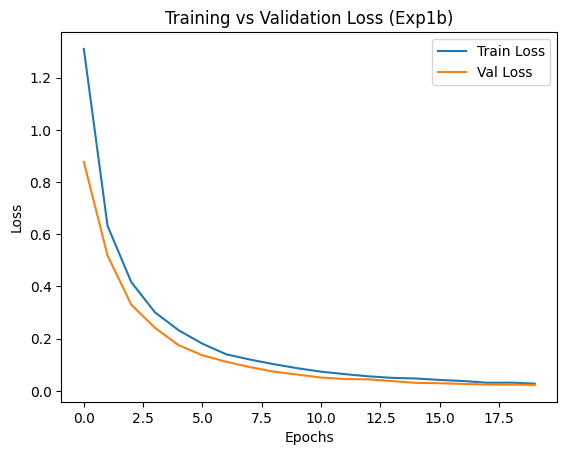

In [101]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exp1b)")
plt.legend()
plt.show()



Final Test Metrics (Experiment 1b):
Accuracy  : 0.9950
Precision : 0.9950
Recall    : 0.9950
F1 Score  : 0.9950

Classification Report:
                  precision    recall  f1-score   support

     Anthracnose       1.00      0.99      0.99        75
Bacterial Canker       1.00      1.00      1.00        75
  Cutting Weevil       1.00      1.00      1.00        75
        Die Back       0.99      1.00      0.99        75
      Gall Midge       1.00      1.00      1.00        75
         Healthy       0.99      1.00      0.99        75
  Powdery Mildew       1.00      0.99      0.99        75
     Sooty Mould       0.99      0.99      0.99        75

        accuracy                           0.99       600
       macro avg       1.00      1.00      0.99       600
    weighted avg       1.00      0.99      0.99       600



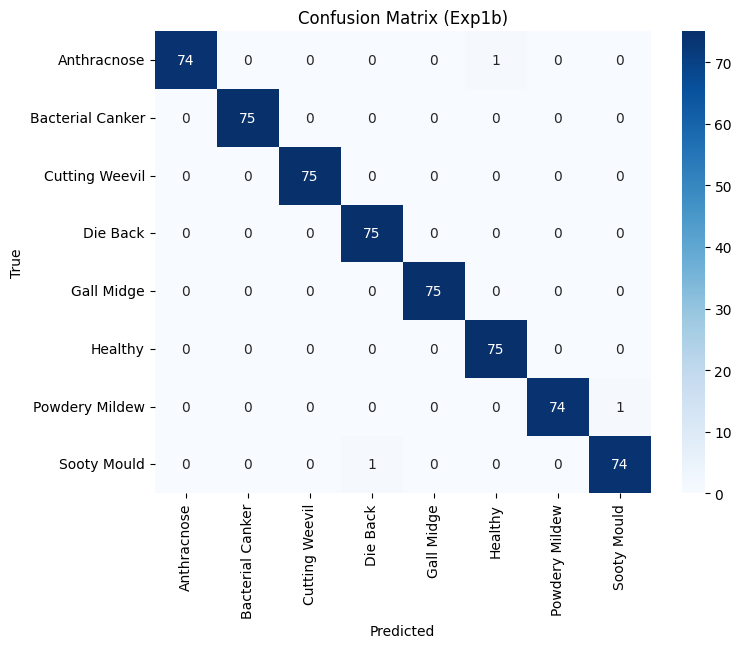

In [102]:
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("\nFinal Test Metrics (Experiment 1b):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Exp1b)")
plt.show()
